# Convergence on congested or not paths

In this experiment we want to check how fast different number of agents will converge, taking into consideration that after increasing the number of agents we can have a congested system in some locations.

## What do we expect to see?

We anticipate a non-linear increase in the number of timesteps required for convergence as the number of vehicles rises.

## Experiment Summary

- **Network Architecture:** Utilization of the Csomor network.
- **Agents:** Altruistic.
- **Number of origins:** 2.
- **Number of destinations:** 2.
- **Origin pairs:**: 279952229#0, 115604053
- **Destination pairs:**: -115602933#2, -441496282#1
- **New agents are created every:** 1 step.
- **Number of paths between origin and destination :** 3.
- **Reinforcement Learning Algorithm:** Proximal Policy Optimization (PPO)

    - **PPO Hyperparameters:**
        - *Gamma:* 0.9
        - *Learning Rate:* 1e-3
        - *Timesteps:* 1000


In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo

from utilities import confirm_env_variable
from utilities import get_params
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

### 1 machine agent

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [1.941379330709966, 4.607439808176691, 1.0589035614245699], (0, 1): [0.7787715086034414, 2.000480192076831, 0.7676270508203282], (1, 0): [0.6873687704023294, 0.9690442195596741, 0.7396357391048572], (1, 1): [3.365846223298535, 3.061644542626266, 2.3841535462277066]}

[SUCCESS] Free flow times calculated!

Agent 0 has origin 1 and destination 1.




In [5]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [6]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    device = "cuda",
    **tuned_params
)

Using cpu device


In [7]:
model.learn(total_timesteps=1000)

---------------------------
| time/              |    |
|    fps             | 2  |
|    iterations      | 1  |
|    time_elapsed    | 4  |
|    total_timesteps | 10 |
---------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2            |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 20           |
| train/                  |              |
|    approx_kl            | 0.0034981011 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 0.00752      |
|    learning_rate        | 0.001        |
|    loss                 | 0.484        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0292      |
|    value_loss           | 1.68         |
------------------------------------------
------------------------------

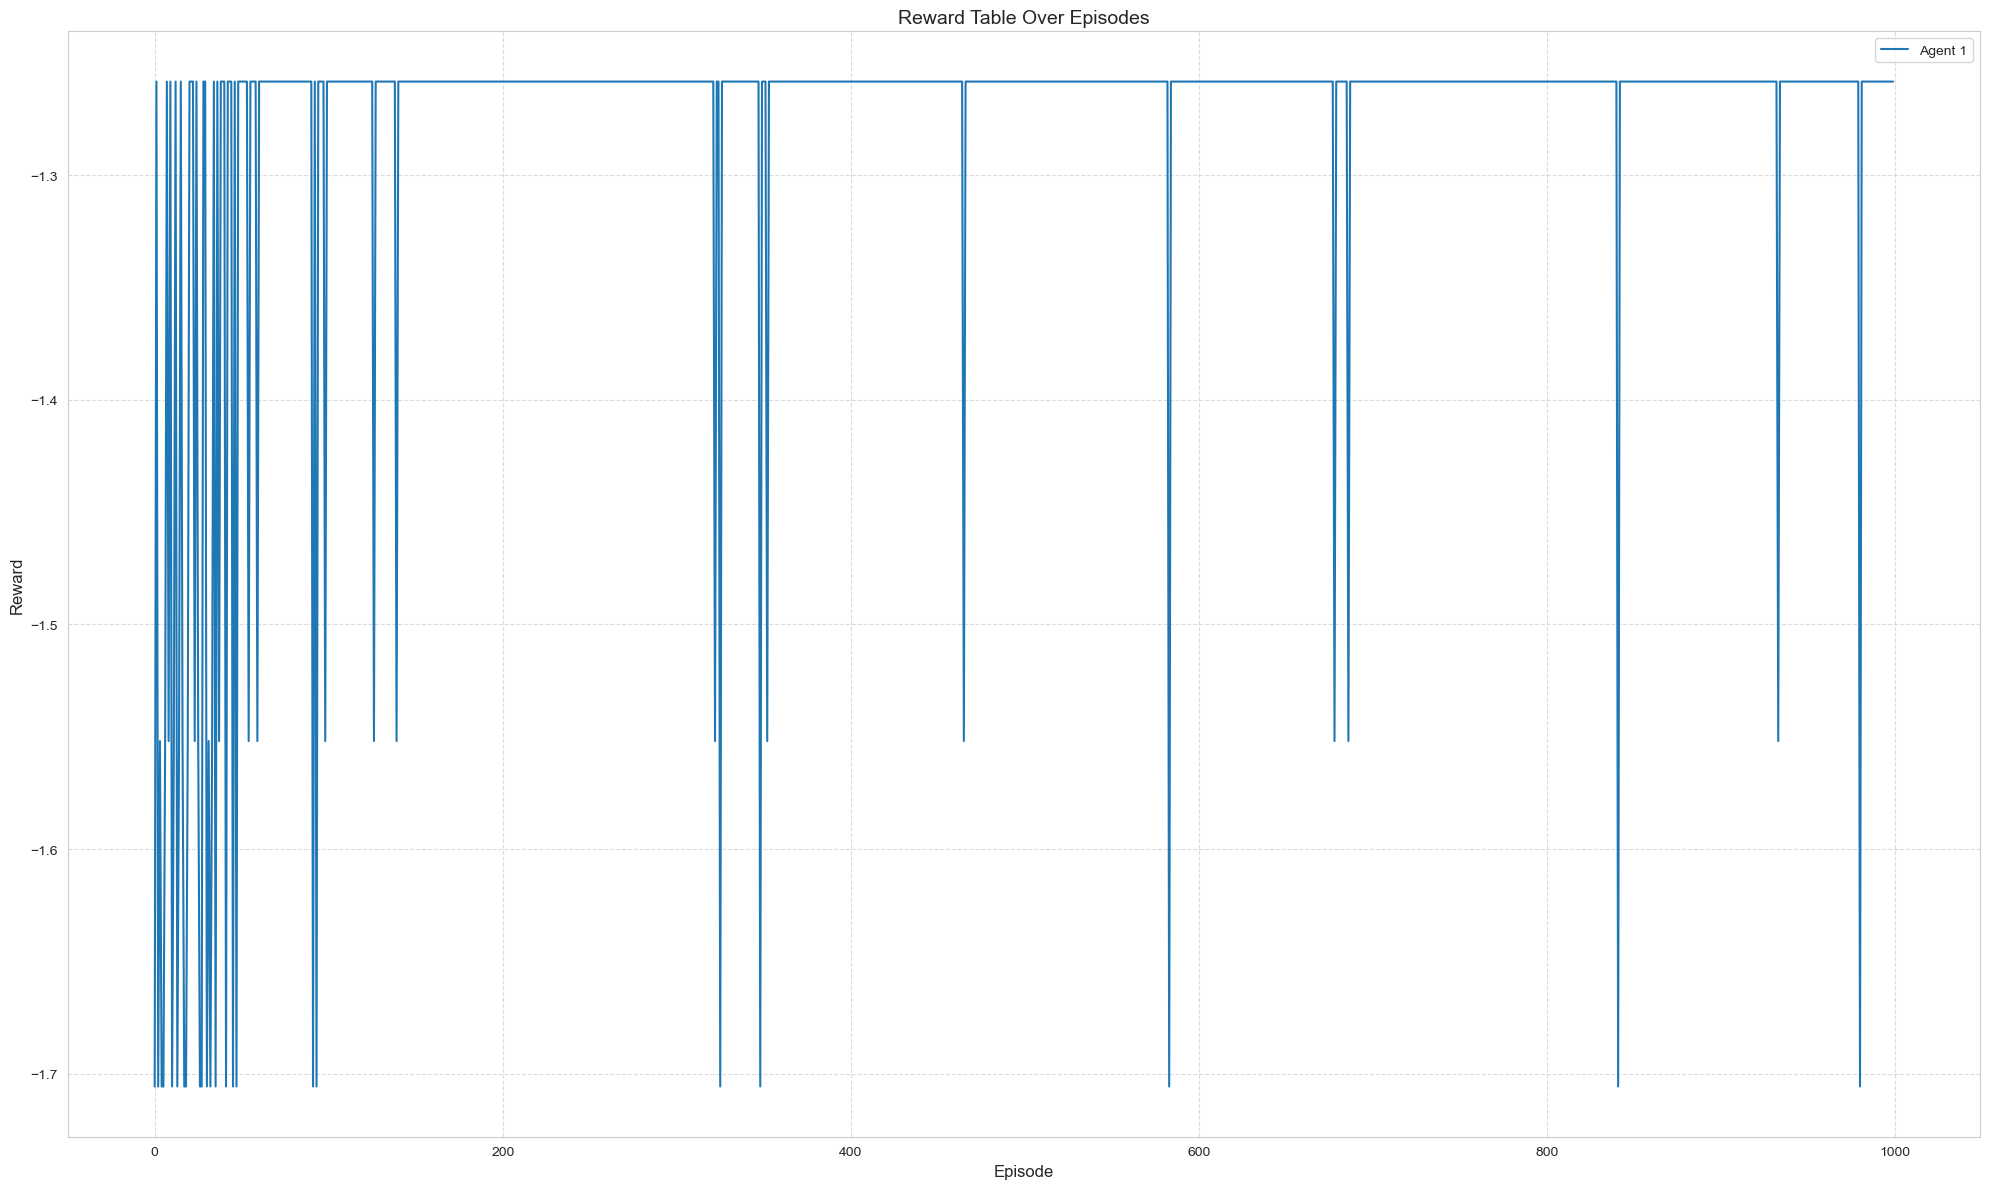

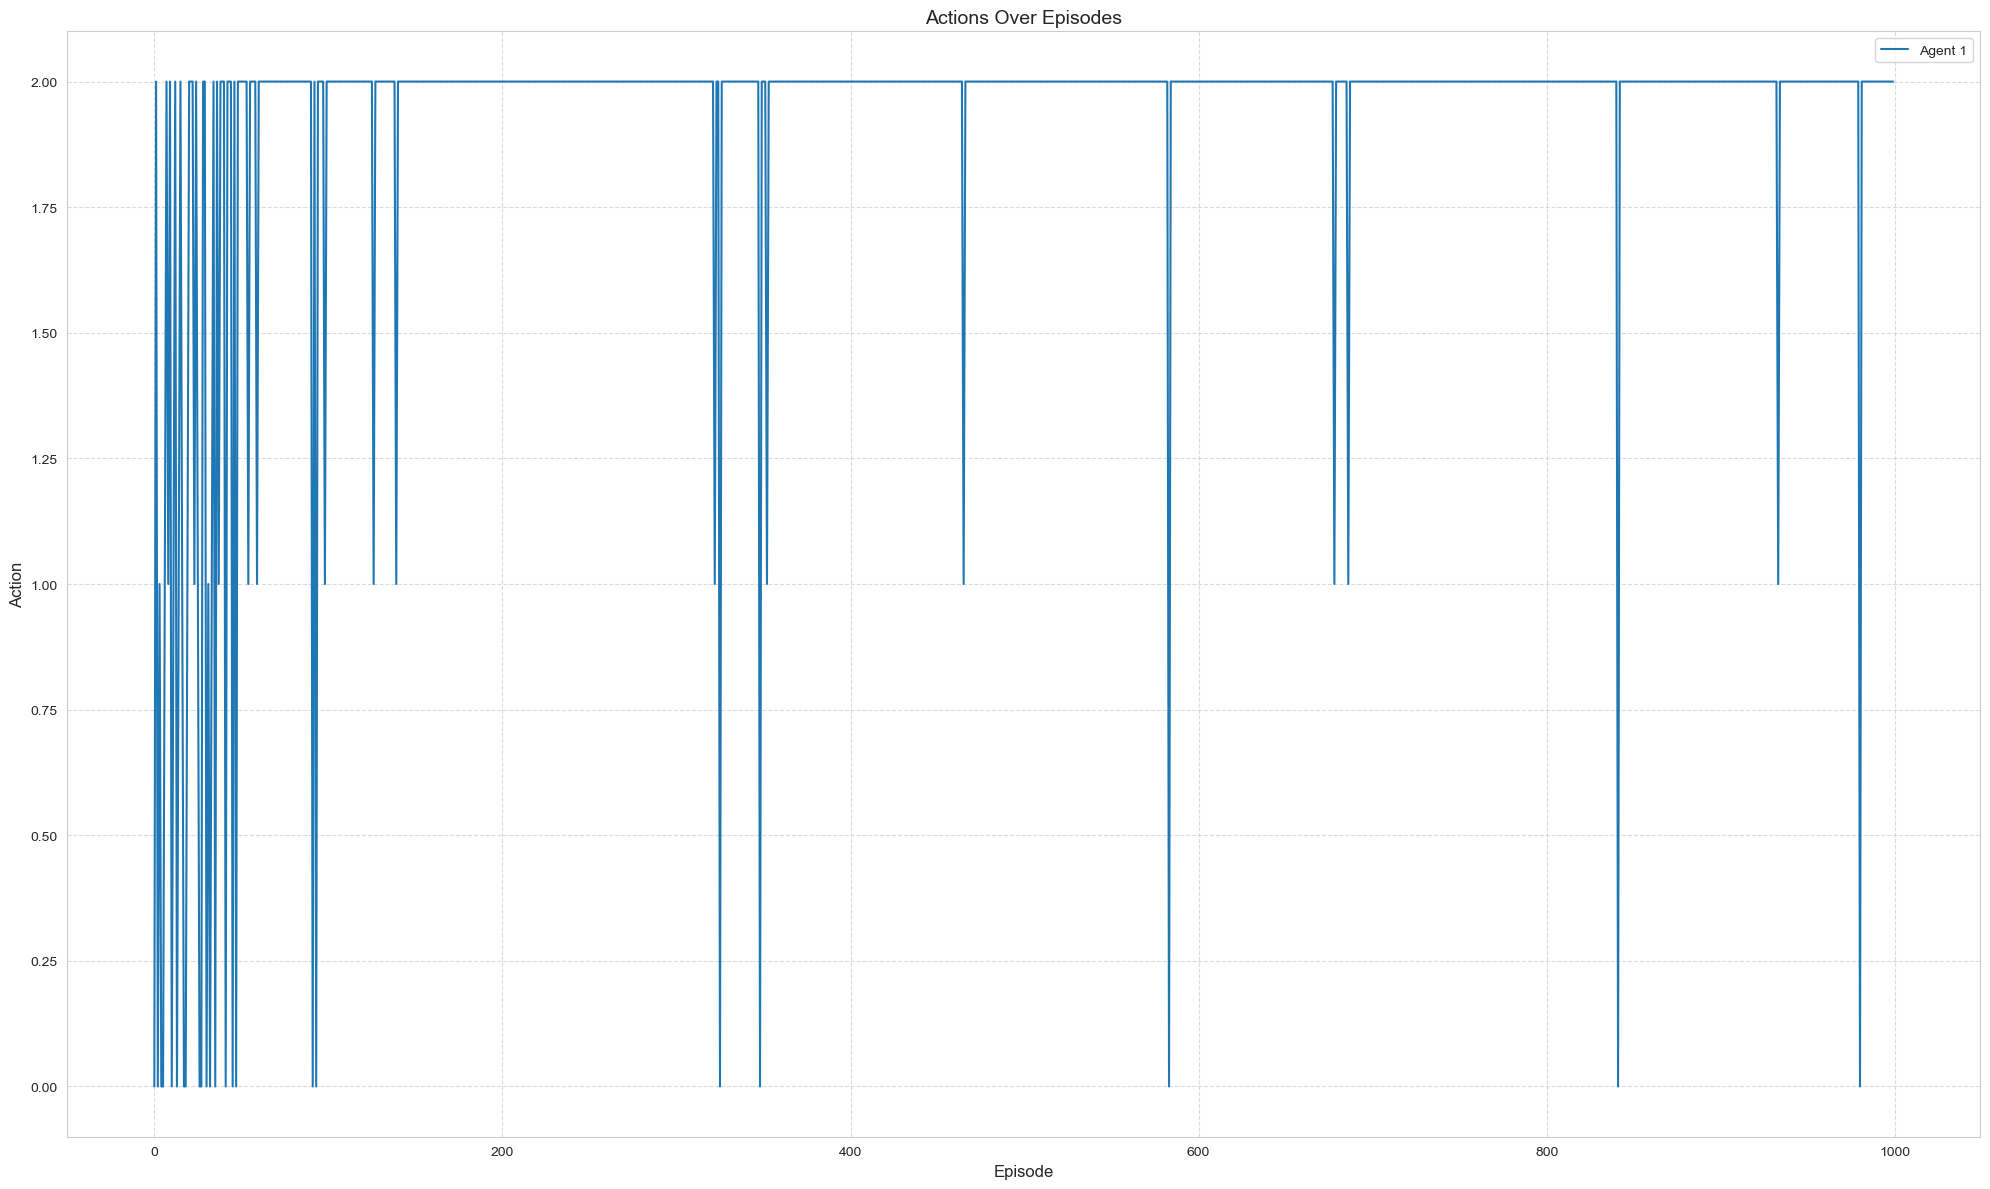

In [8]:
env.close()

### 100 machine agents

![](100agentsCongestion.png)

In [17]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [2.0711284513805523, 2.067767106842737, 2.4059623849539817], (0, 1): [3.3475390156062423, 0.7787715086034414, 1.1184673869547819], (1, 0): [6.452901045227305, 0.6873687704023294, 1.7828040100751665], (1, 1): [2.9059250338004174, 2.9385553069319883, 2.3220426399501486]}

[SUCCESS] Free flow times calculated!

Agent 0 has origin 0 and destination 1.



Agent 1 has origin 1 and destination 0.



Agent 2 has origin 1 and destination 0.



Agent 3 has origin 1 and destination 0.



Agent 4 has origin 0 and destination 1.



Agent 5 has origin 0 and destination 1.



Agent 6 has origin 0 and destination 0.



Agent 7 has origin 1 and destination 1.



Agent 8 has origin 0 and destination 0.



Agent 9 has origin 0 and destination 1.



Agent 10 has origin 1 and destination 1.



Agent 11 has origin 0 and d

In [18]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [19]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    device = "cuda",
    **tuned_params
)

Using cpu device


In [20]:
model.learn(total_timesteps=100000)

-----------------------------
| time/              |      |
|    fps             | 186  |
|    iterations      | 1    |
|    time_elapsed    | 5    |
|    total_timesteps | 1000 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 149         |
|    iterations           | 2           |
|    time_elapsed         | 13          |
|    total_timesteps      | 2000        |
| train/                  |             |
|    approx_kl            | 0.011666793 |
|    clip_fraction        | 0.0849      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.0058     |
|    learning_rate        | 0.001       |
|    loss                 | -0.0401     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00687    |
|    value_loss           | 1.27        |
-----------------------------------------
----------------------------------

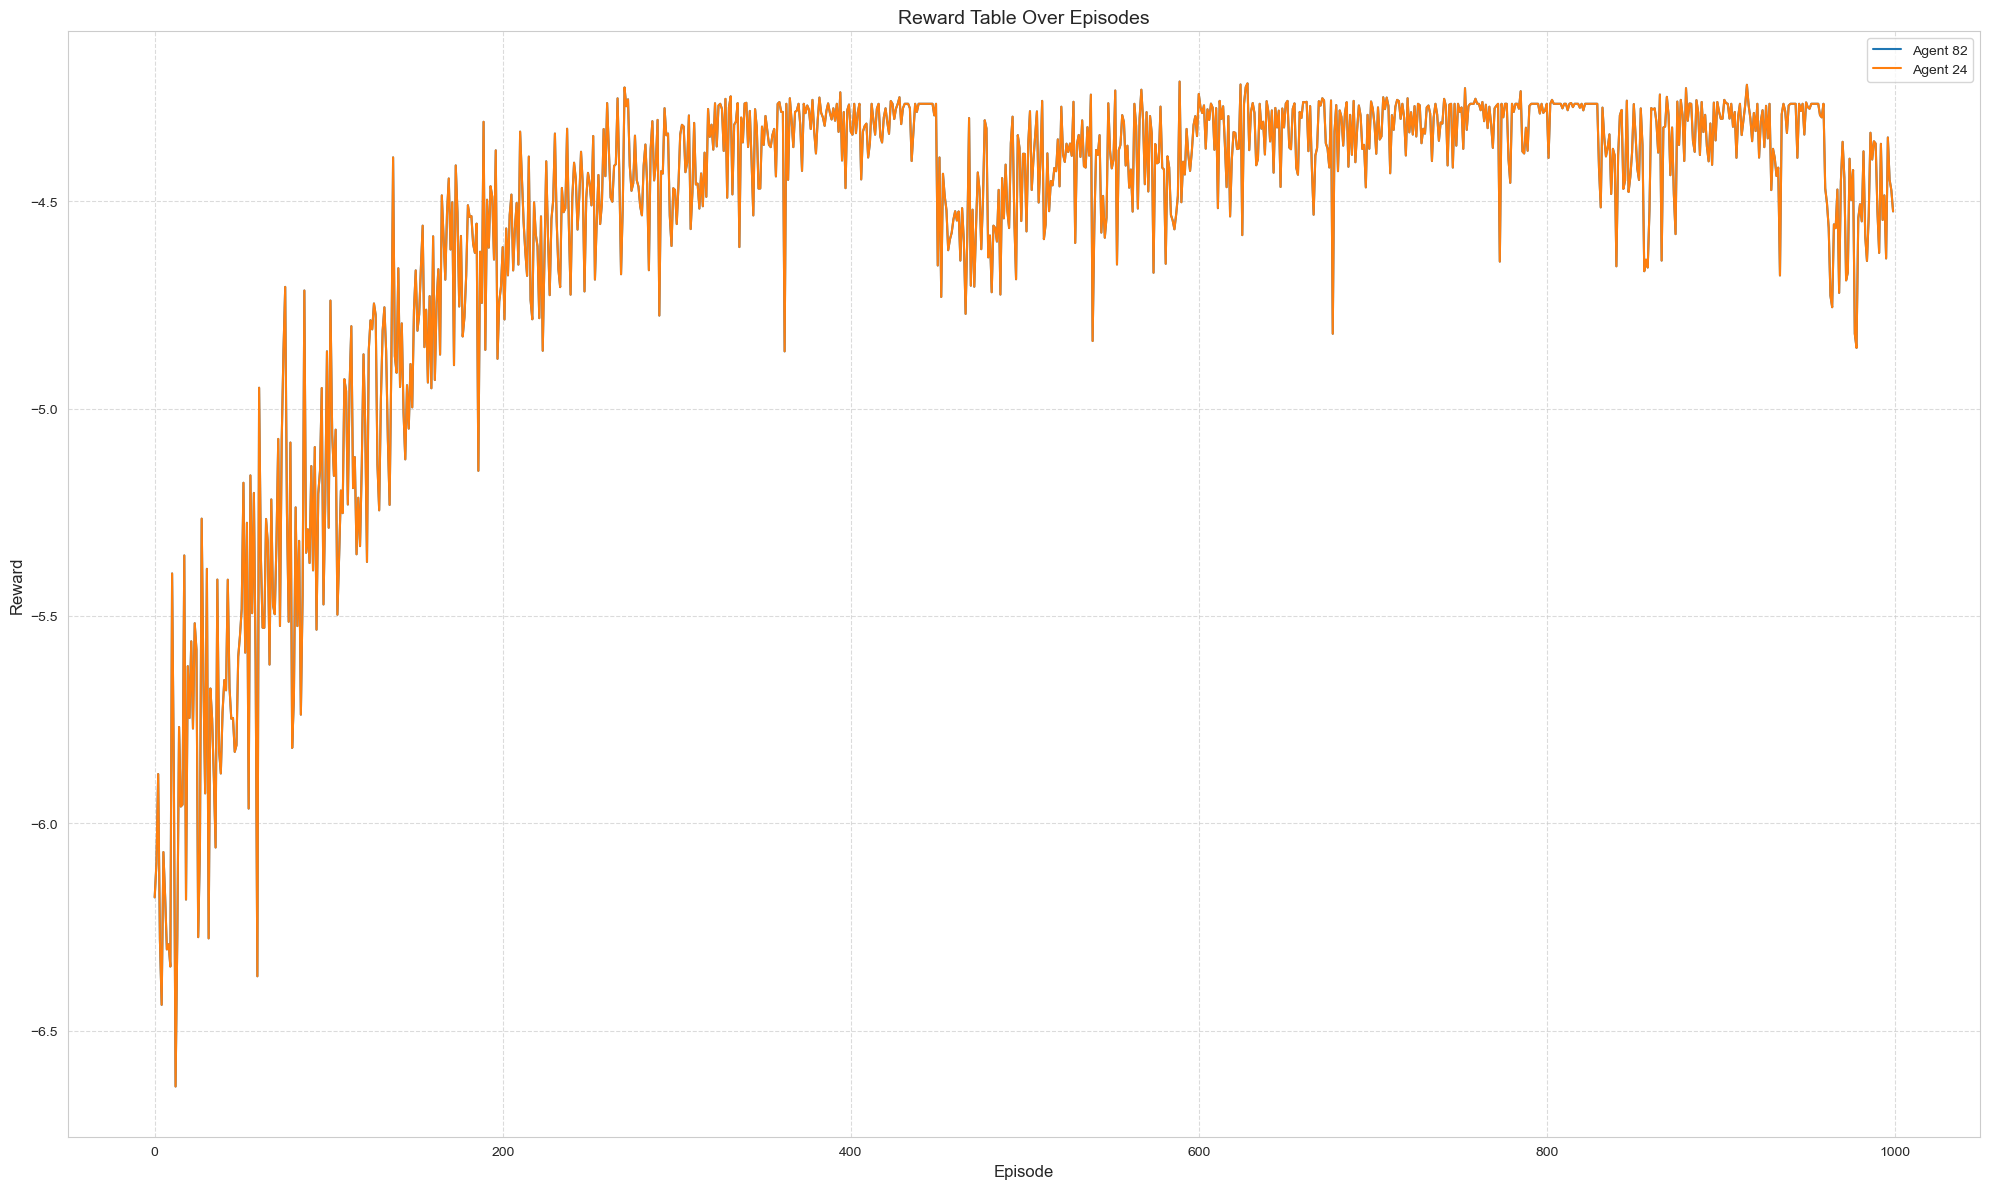

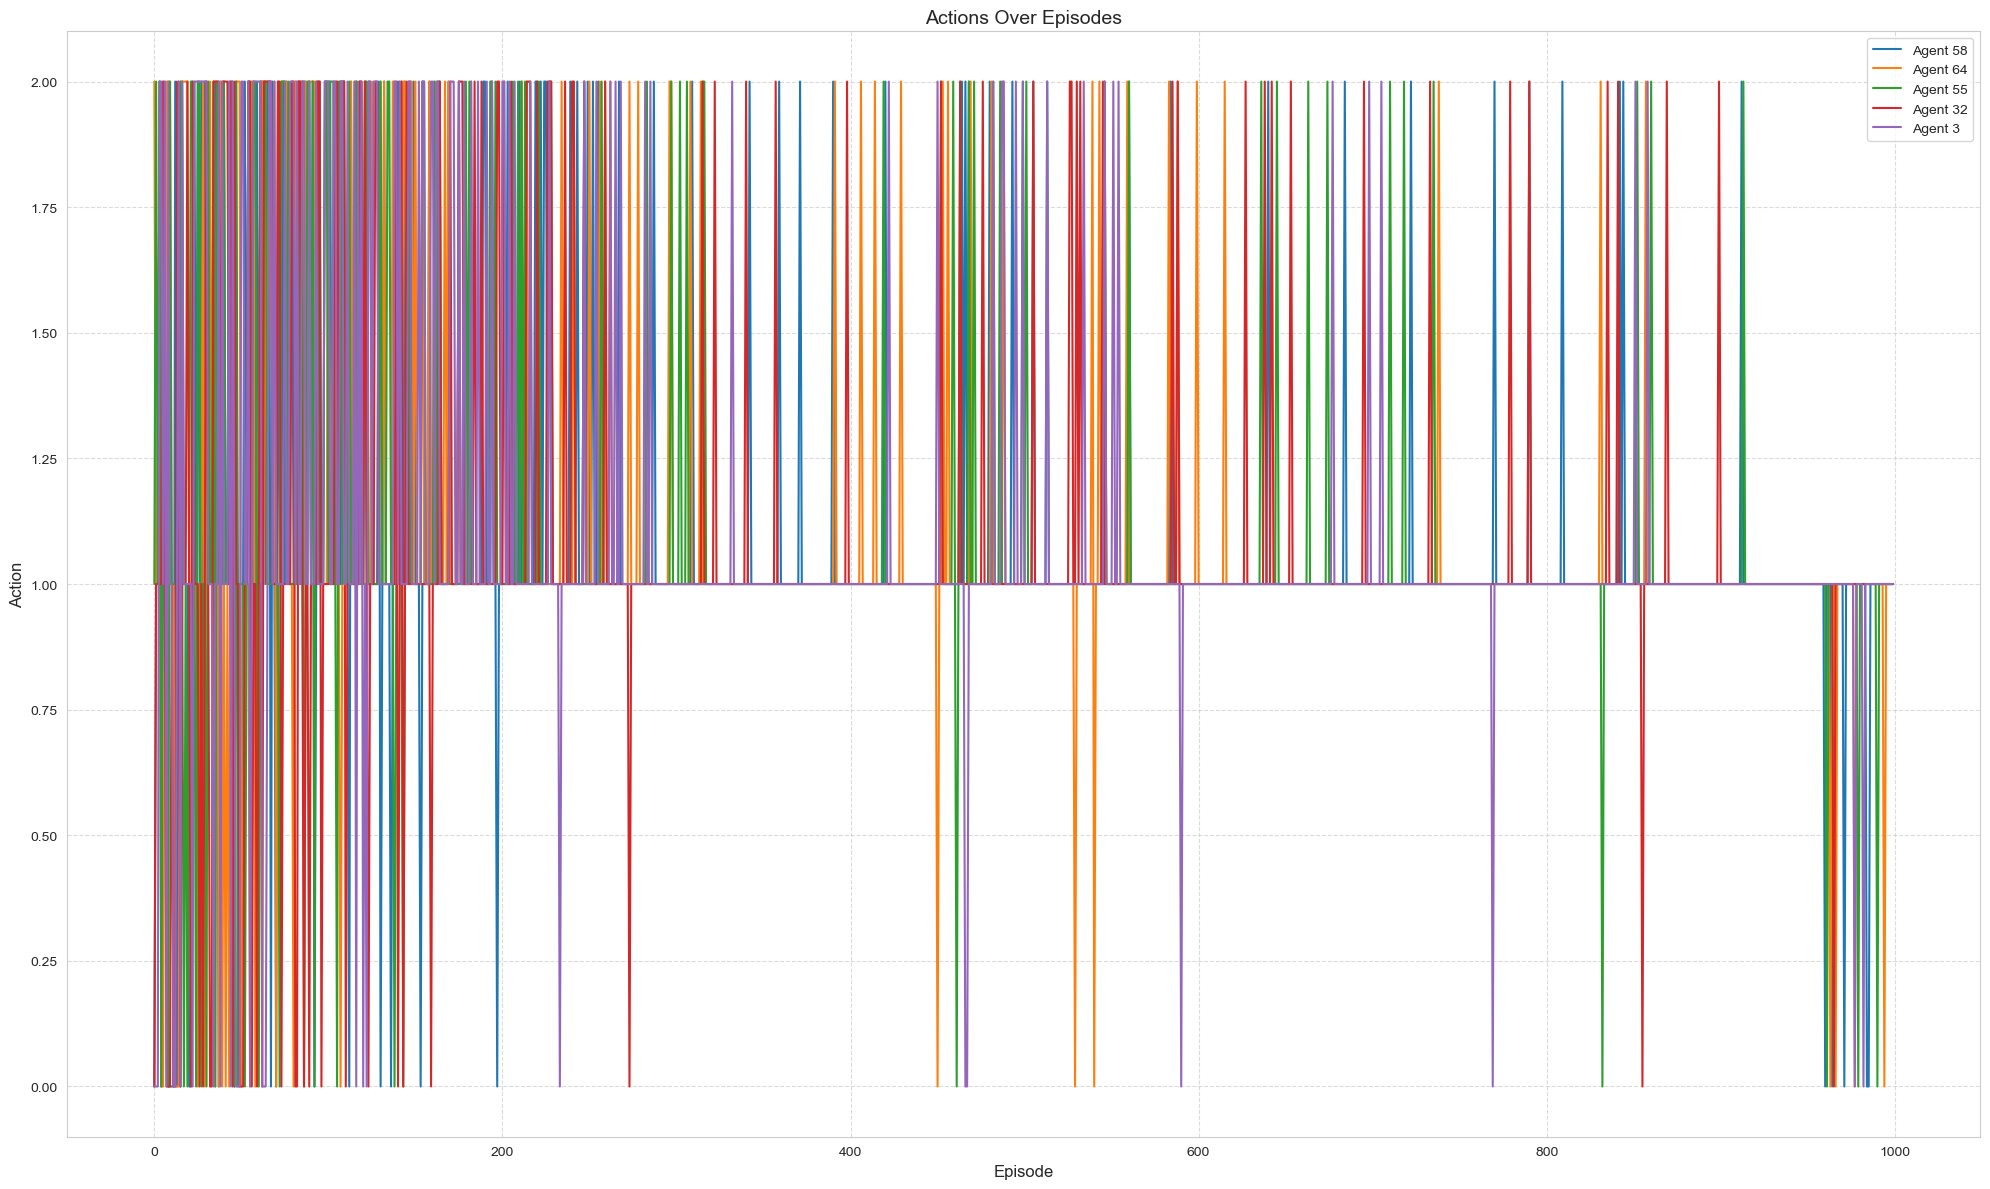

In [21]:
env.close()

In [22]:
model.learn(total_timesteps=500000)

-----------------------------
| time/              |      |
|    fps             | 192  |
|    iterations      | 1    |
|    time_elapsed    | 5    |
|    total_timesteps | 1000 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 158          |
|    iterations           | 2            |
|    time_elapsed         | 12           |
|    total_timesteps      | 2000         |
| train/                  |              |
|    approx_kl            | 0.0009487538 |
|    clip_fraction        | 0.0162       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.164       |
|    explained_variance   | 0.000721     |
|    learning_rate        | 0.001        |
|    loss                 | 0.00896      |
|    n_updates            | 1010         |
|    policy_gradient_loss | 0.0013       |
|    value_loss           | 0.0171       |
------------------------------------------
----------------

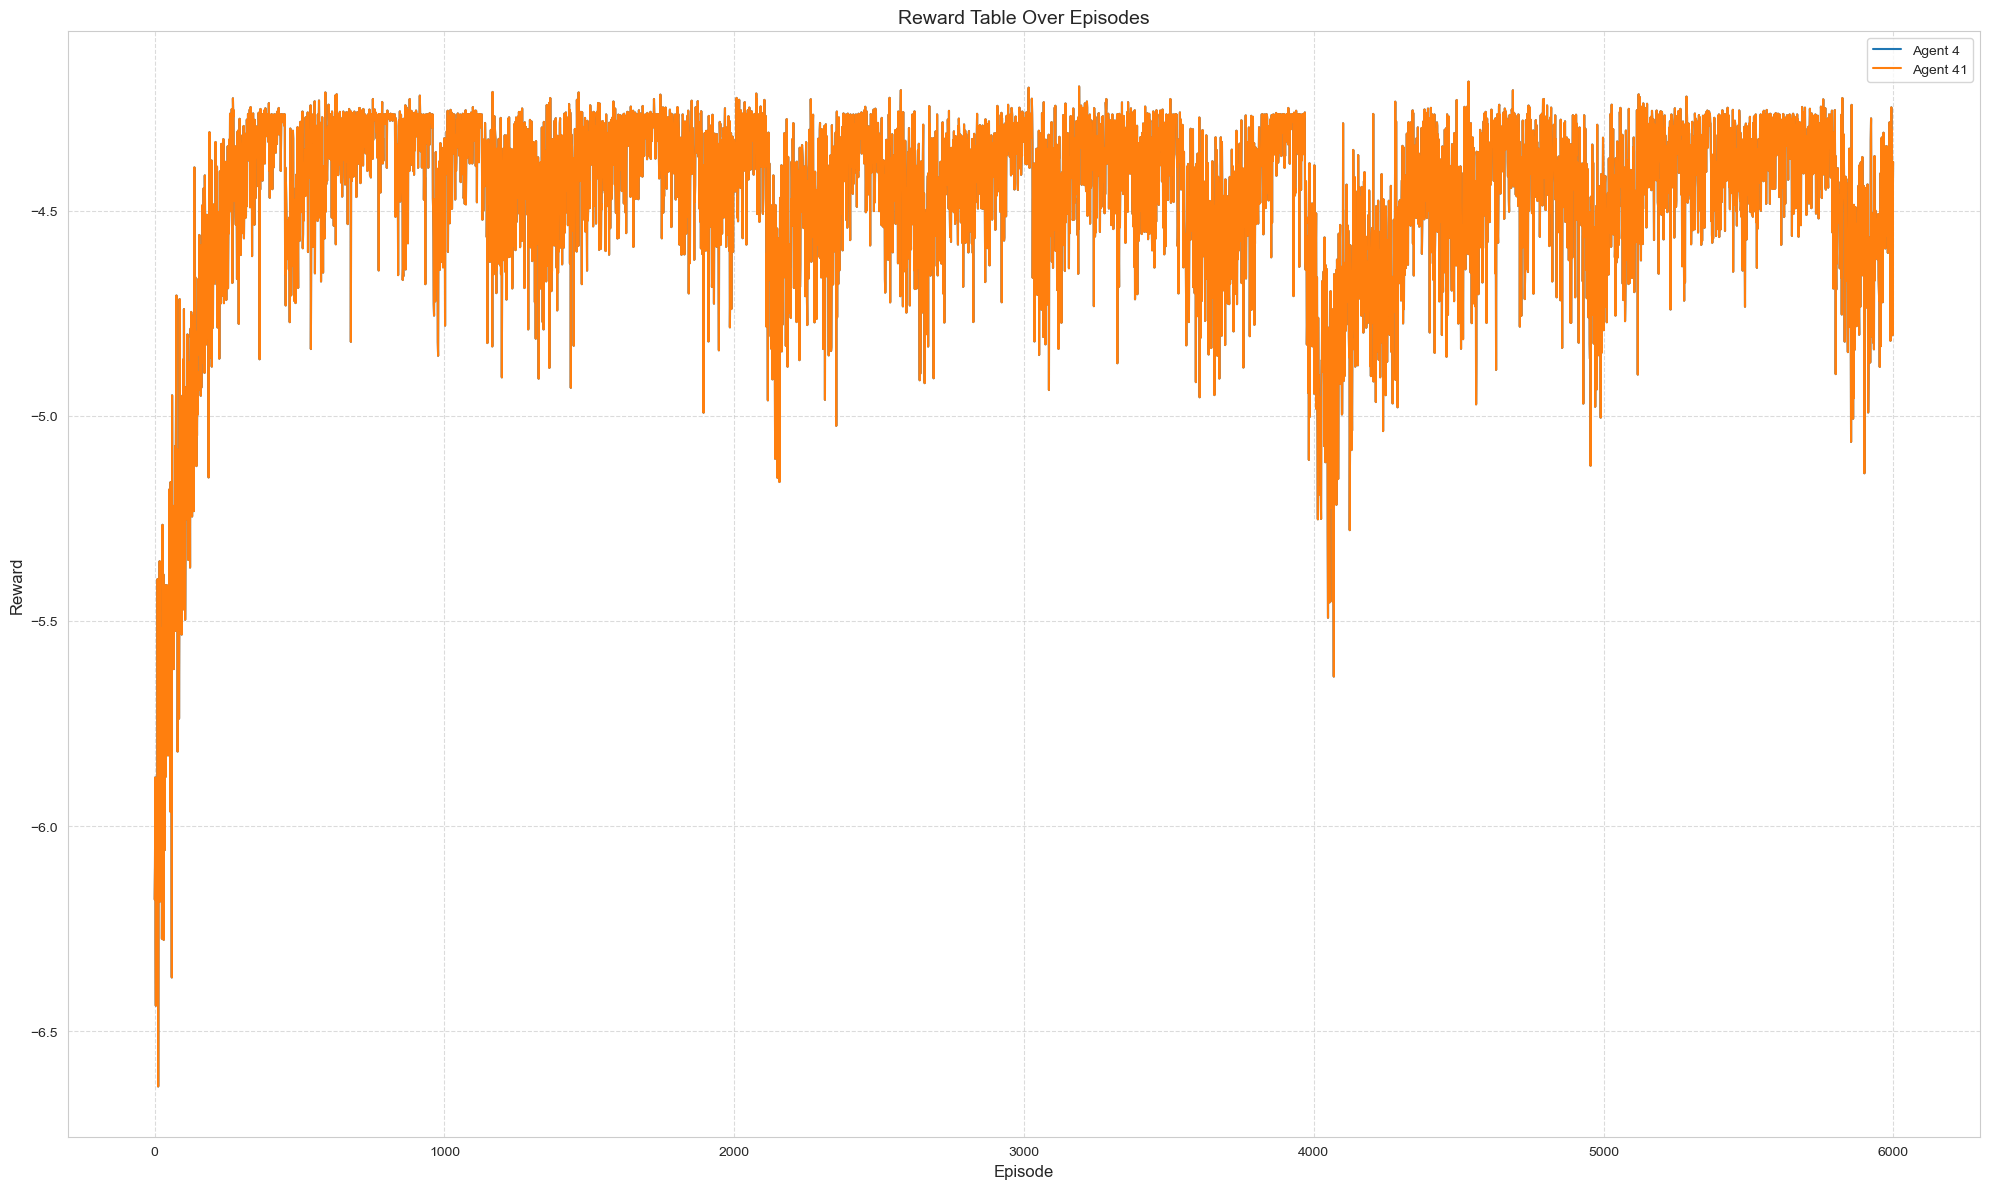

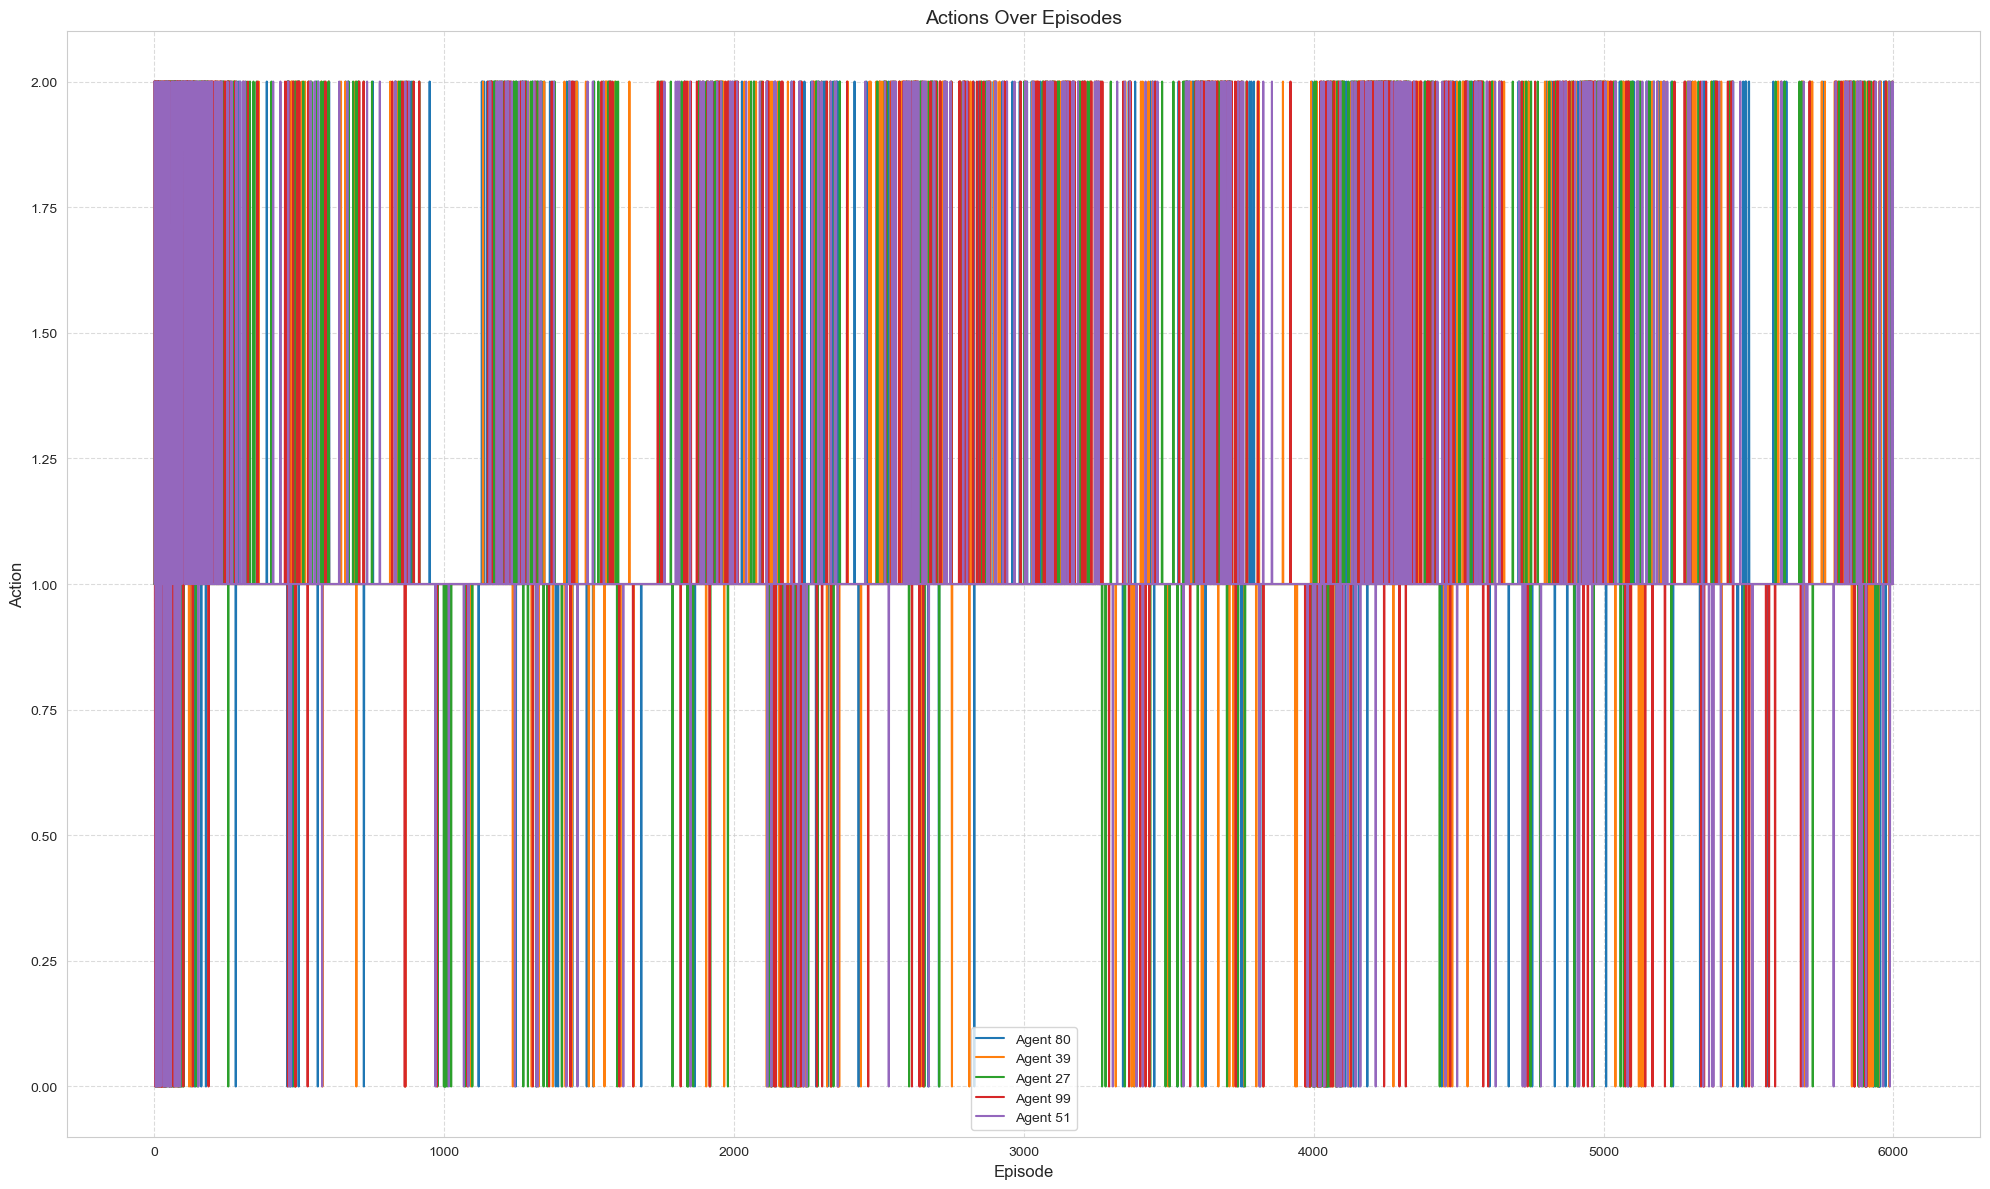

In [23]:
env.close()

### 600 machine agents

![](600agentsCongestion.png)

In [ ]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

In [ ]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [ ]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    device = "cuda",
    **tuned_params
)

In [ ]:
model.learn(total_timesteps=1000000)

In [ ]:
env.close()

### 1000 machine agents

![](1000agentsCongestion.png)

In [11]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [1.07202881152461, 1.0589035614245699, 3.2279311724689874], (0, 1): [0.7787715086034414, 0.7676270508203282, 3.2450247341557215], (1, 0): [0.7396357391048572, 1.834679084016616, 0.6873687704023294], (1, 1): [1.9106208502119348, 3.061644542626266, 2.235948202175038]}

[SUCCESS] Free flow times calculated!

Agent 0 has origin 0 and destination 0.



Agent 1 has origin 0 and destination 1.



Agent 2 has origin 1 and destination 0.



Agent 3 has origin 1 and destination 1.



Agent 4 has origin 1 and destination 1.



Agent 5 has origin 0 and destination 1.



Agent 6 has origin 1 and destination 0.



Agent 7 has origin 0 and destination 0.



Agent 8 has origin 0 and destination 0.



Agent 9 has origin 1 and destination 1.



Agent 10 has origin 1 and destination 0.



Agent 11 has origin 0 and dest

In [12]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [13]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    device = "cuda",
    **tuned_params
)

Using cpu device


In [14]:
model.learn(total_timesteps=1000000)

------------------------------
| time/              |       |
|    fps             | 463   |
|    iterations      | 1     |
|    time_elapsed    | 21    |
|    total_timesteps | 10000 |
------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 257         |
|    iterations           | 2           |
|    time_elapsed         | 77          |
|    total_timesteps      | 20000       |
| train/                  |             |
|    approx_kl            | 0.007541739 |
|    clip_fraction        | 0.0147      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -3.62e-05   |
|    learning_rate        | 0.001       |
|    loss                 | 0.119       |
|    n_updates            | 10          |
|    policy_gradient_loss | -9.12e-05   |
|    value_loss           | 2.36        |
-----------------------------------------
---------------------------

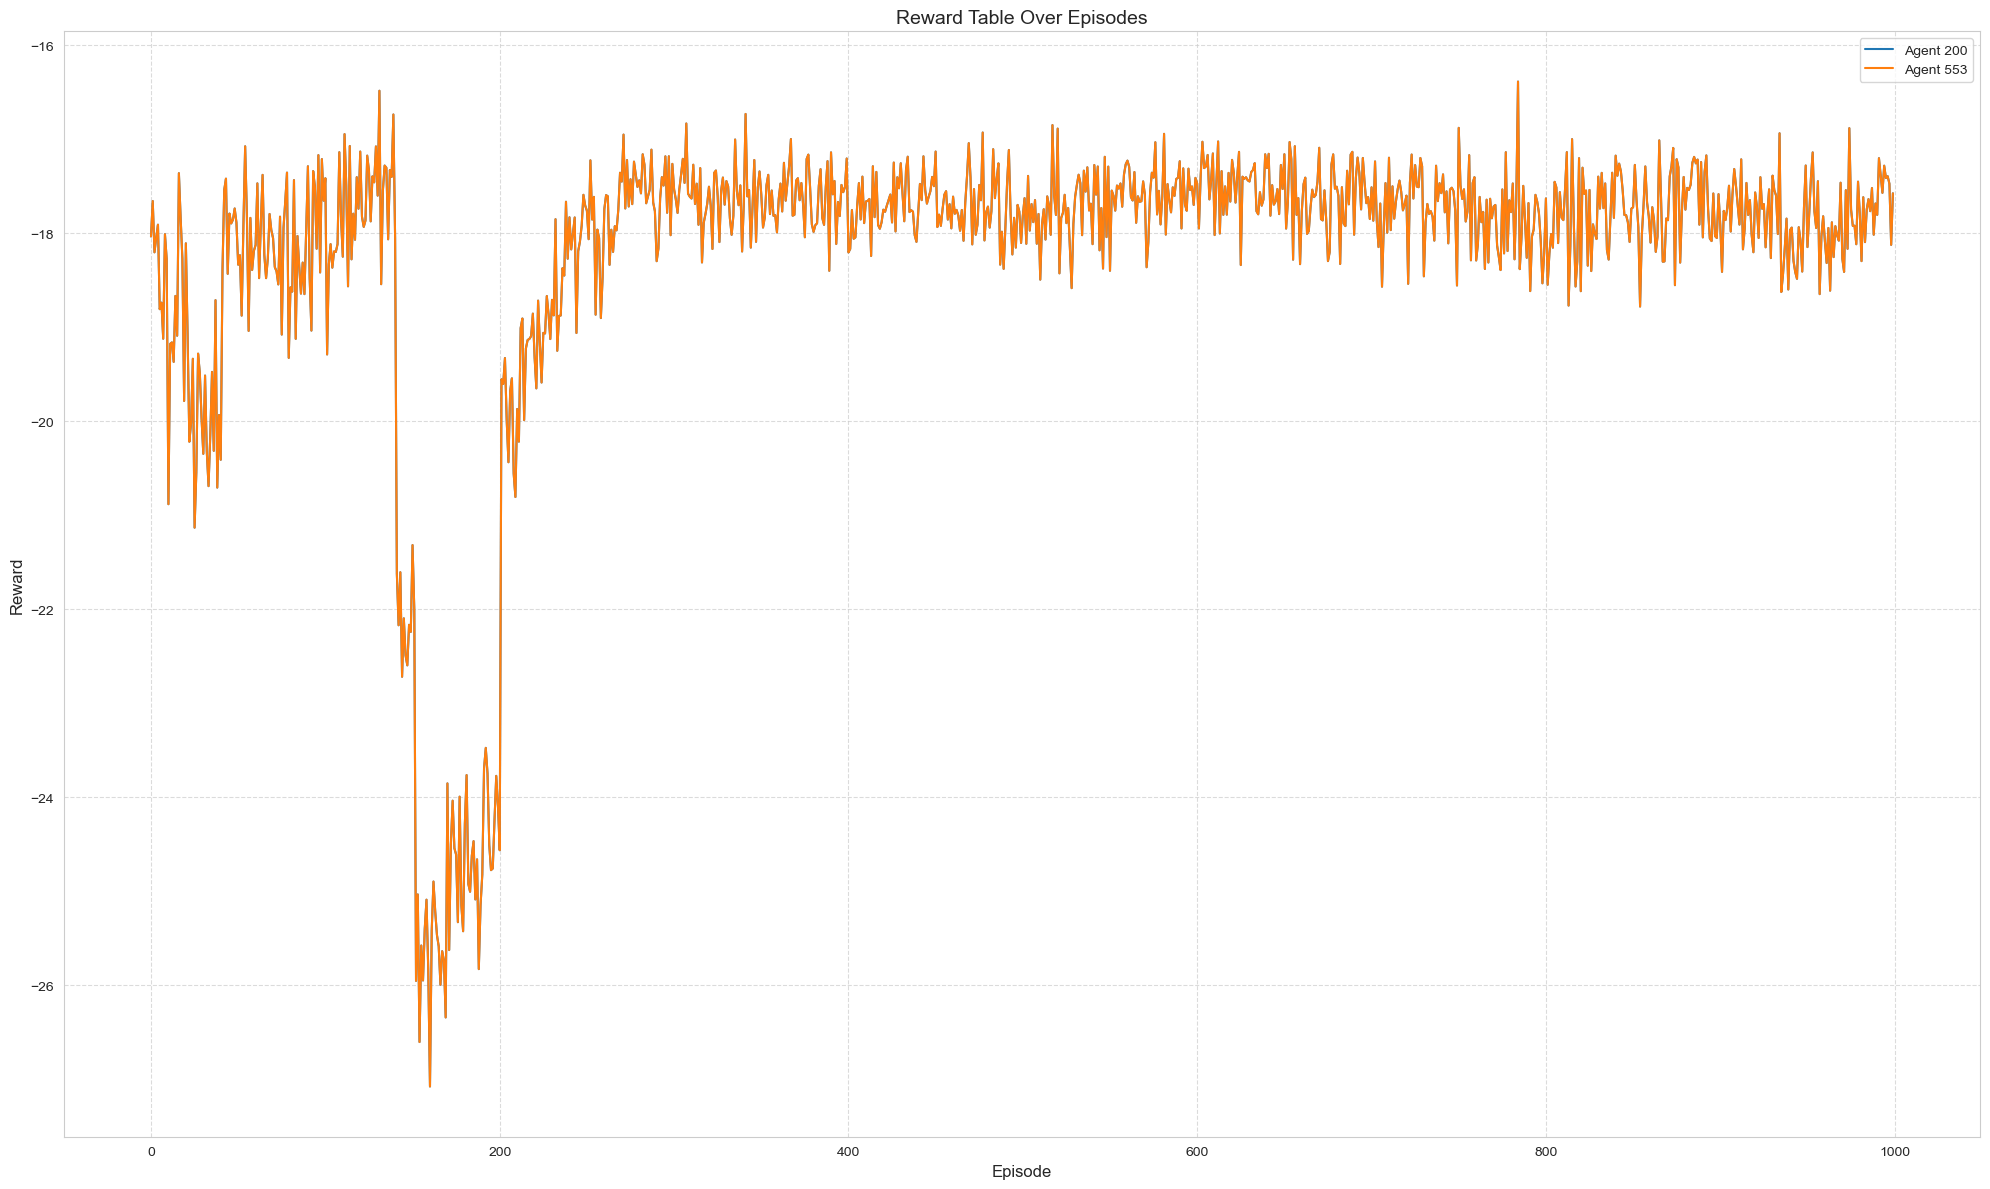

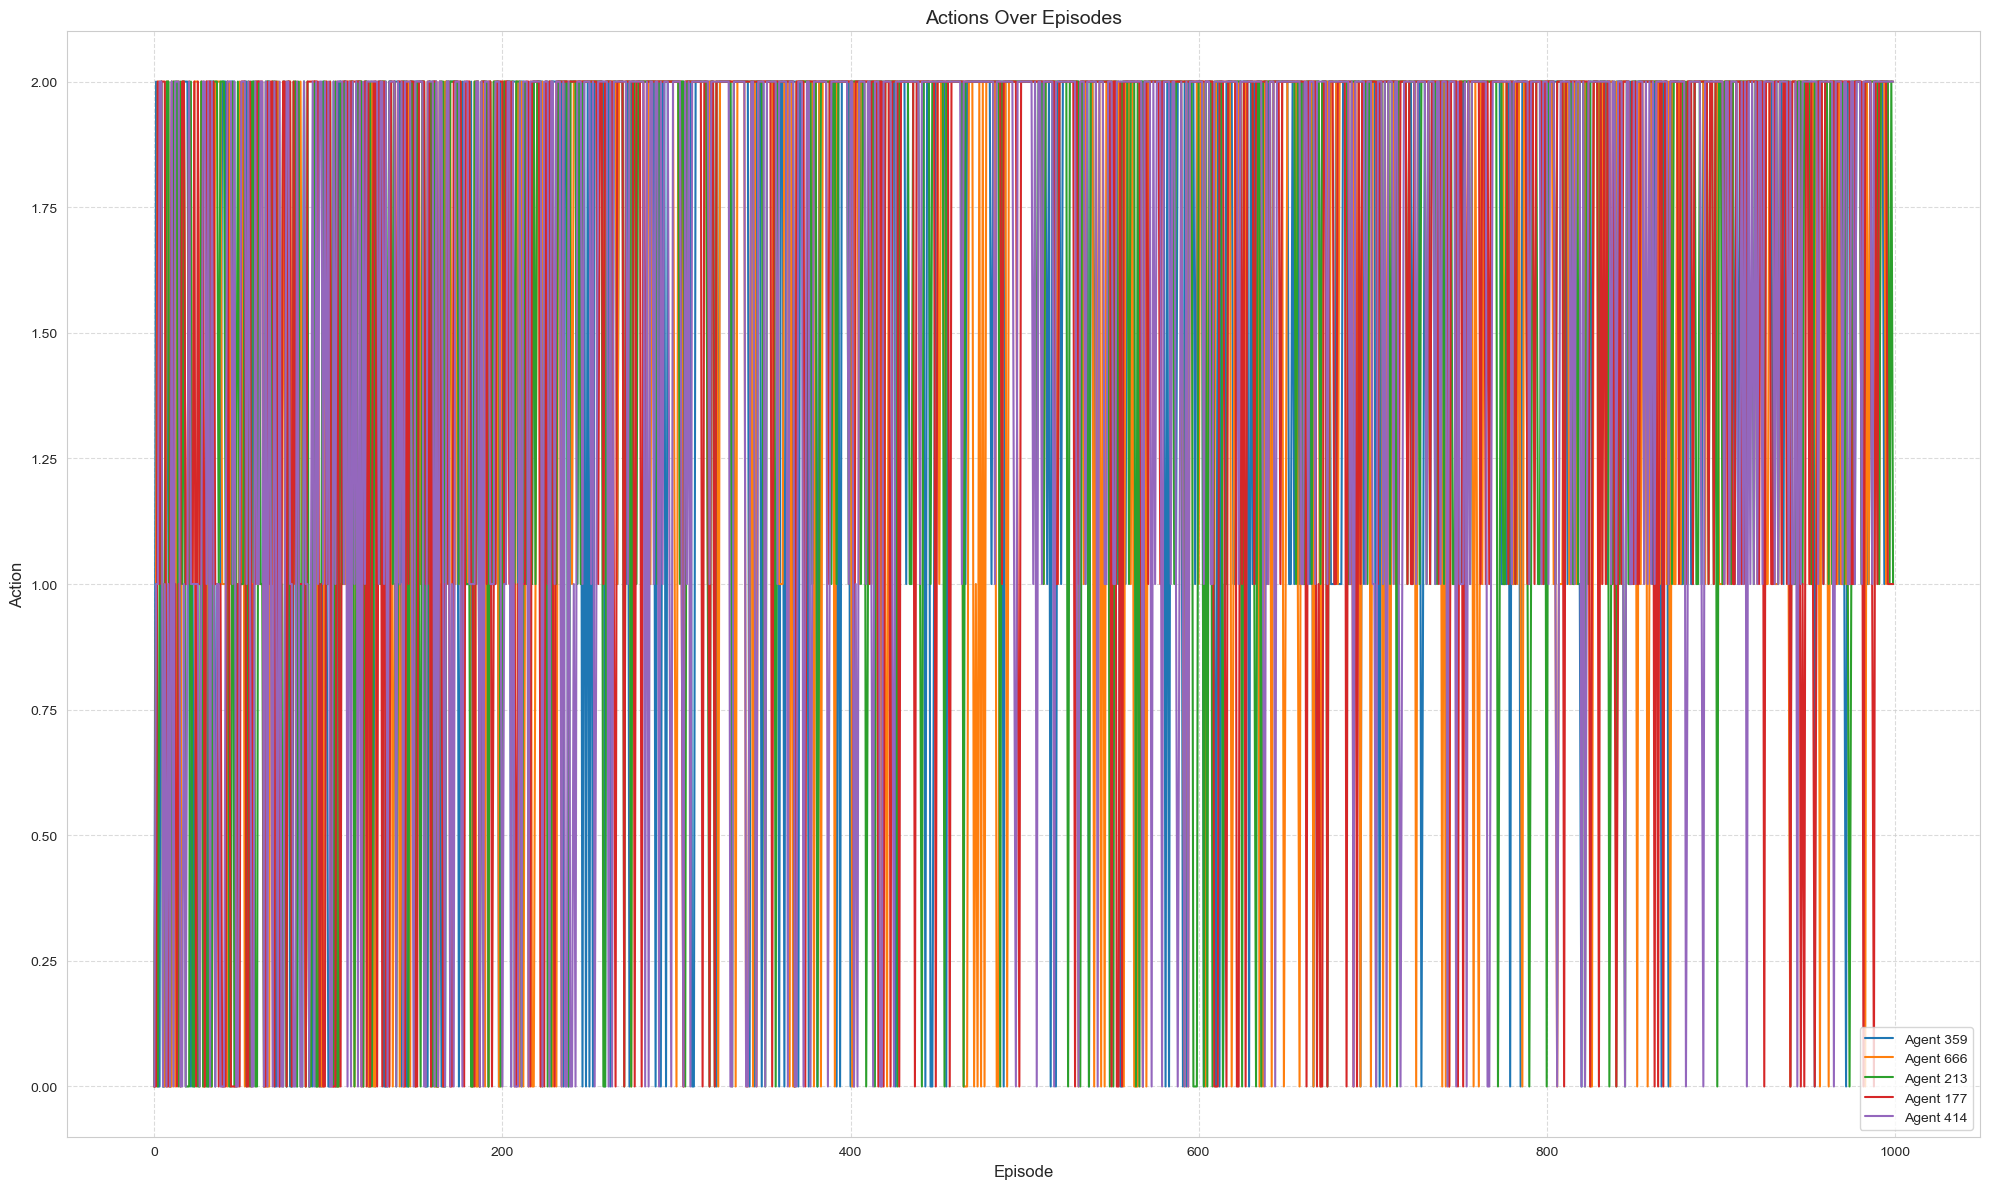

In [15]:
env.close()

## Conclusions

#### Random observation

In this notebook the origin and destination pairs are quite close to each other, compared to the experiments on the other notebooks. This has led to faster execution of the code, probably because SUMO takes less time to calculate the travel times on smaller paths. 